<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <img src="../assets/branding/logoUgrupo.png" alt="Universidad del Magdalena y GIDSYC" style="height: 76px; max-width: 34%; object-fit: contain;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Modelos de difusión para IA generativa</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 01</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Ruido gaussiano y espacios de datos</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Semillero GIDSYC | Facultad de Ingenierías | Programa de Ingeniería de Sistemas</div>
    </div>
    <img src="../assets/branding/logo_semillero.png" alt="Semillero GIDSYC" style="height: 74px; object-fit: contain;">
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
  <div><strong>Grupo:</strong> GIDSYC</div>
  <div><strong>Unidad:</strong> Semillero GIDSYC</div>
  <div><strong>Universidad:</strong> Universidad del Magdalena</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>

## Pregunta directriz

> Si el ruido gaussiano no tiene estructura visual, ¿por qué es un punto de partida natural para los modelos generativos modernos?

El Notebook 00 formuló la generación como aproximación de una distribución de datos. En este notebook estudiamos la otra distribución que aparecerá de forma recurrente en el curso: la distribución gaussiana estándar. La idea central es que el ruido no se usa porque se parezca a los datos, sino porque es una distribución simple, conocida, fácil de muestrear y matemáticamente estable en espacios de alta dimensión.

## Objetivos

Al finalizar este notebook, el estudiante debería estar en capacidad de:

1. Formular el ruido gaussiano estándar como una distribución en $\mathbb{R}^d$.
2. Interpretar una imagen de ruido como un punto del mismo espacio vectorial que una imagen de datos.
3. Explicar por qué $\mathcal{N}(0,I)$ es una distribución base útil para modelos generativos.
4. Reconocer el fenómeno de concentración de norma en gaussianas de alta dimensión.
5. Distinguir entre facilidad de muestreo y estructura semántica.

## Marco conceptual

Un modelo generativo necesita producir muestras de una distribución compleja $p_{\mathrm{data}}(x)$, pero esta distribución no suele ser conocida de forma explícita. En cambio, sí conocemos distribuciones simples de las que podemos muestrear directamente. La gaussiana estándar es la elección más común:

$$
z \sim \mathcal{N}(0,I).
$$

En modelos de difusión, flow matching y otros enfoques modernos, la generación puede verse como la construcción de un puente entre una distribución simple y una distribución estructurada. Este notebook no construye todavía ese puente. Su propósito es estudiar el extremo inicial: el ruido gaussiano como distribución de referencia en el mismo espacio donde viven los datos.

La pregunta relevante no es si una muestra gaussiana se parece a una casa. Claramente no. La pregunta relevante es si podemos partir de una distribución simple y aprender una transformación que lleve sus muestras hacia regiones de alta probabilidad bajo la distribución de datos.

## Formulación matemática

Sea $d$ la dimensión del espacio de datos. Para imágenes de QuickDraw de tamaño $28 \times 28$, tenemos:

$$
d = 28 \cdot 28 = 784.
$$

La distribución gaussiana estándar en $\mathbb{R}^d$ se define como:

$$
z \sim \mathcal{N}(0,I_d).
$$

La notación $I_d$ representa la matriz identidad de tamaño $d \times d$:

$$
I_d =
\begin{bmatrix}
1 & 0 & \cdots & 0 \\
0 & 1 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & 1
\end{bmatrix}.
$$

Por tanto, escribir $z \sim \mathcal{N}(0,I_d)$ significa que el vector aleatorio tiene media cero y matriz de covarianza identidad:

$$
\mathbb{E}[z] = 0, \qquad \mathrm{Cov}(z) = I_d.
$$

Esta forma compacta dice algo muy concreto: cada coordenada de $z$ tiene varianza uno y las coordenadas no están correlacionadas entre sí. En la gaussiana multivariada, esa falta de correlación implica independencia. Equivalentemente, podemos escribir:

$$
z = (z_1, z_2, \ldots, z_d)^\top,
\qquad
z_j \sim \mathcal{N}(0,1),
\qquad
z_i \perp z_j \; \text{si } i \neq j.
$$

Su densidad está dada por:

$$
p(z)
=
\frac{1}{(2\pi)^{d/2}}
\exp\left(-\frac{1}{2}\|z\|^2\right).
$$

Esta expresión muestra dos propiedades importantes. Primero, la densidad depende de $z$ únicamente a través de su norma euclidiana $\|z\|$, de modo que la distribución no privilegia una dirección específica del espacio. Esta propiedad se llama isotropía: si giramos el sistema de coordenadas, la distribución se ve igual. En términos intuitivos, antes de aprender de los datos, el ruido gaussiano no trae una orientación preferida ni una estructura espacial privilegiada. Segundo, muestrear de esta distribución es computacionalmente directo: basta generar $d$ variables normales independientes, exactamente el tipo de operación que implementamos con un generador pseudoaleatorio.

En dimensión alta, la norma de una muestra gaussiana no se comporta como en dimensión uno. Si $z \sim \mathcal{N}(0,I_d)$, entonces:

$$
\|z\|^2 = \sum_{j=1}^{d} z_j^2 \sim \chi^2_d,
$$

por lo tanto:

$$
\mathbb{E}\left[\|z\|^2\right] = d.
$$

En consecuencia, una muestra típica no aparece cerca del origen, sino alrededor de una región de radio aproximado $\sqrt{d}$. Este fenómeno será importante para entender por qué el ruido en alta dimensión tiene estructura estadística aunque no tenga estructura semántica.


<div style="text-align: center; margin: 18px 0 8px 0;">
  <img src="../assets/figures/formulacion_ruido_gaussiano.png" alt="Lectura geométrica de la distribución gaussiana estándar" style="width: 100%; max-width: 1100px;">
</div>

La figura resume la lectura geométrica de $z \sim \mathcal{N}(0,I_d)$. La matriz identidad indica varianza unitaria por coordenada y ausencia de covarianzas; en dos dimensiones esto produce contornos circulares, una señal visual de isotropía. Ninguna dirección del plano recibe más variabilidad que otra. En alta dimensión, esta simetría convive con un fenómeno menos intuitivo: la masa de probabilidad se concentra alrededor de un radio típico cercano a $\sqrt{d}$.


## Preparación del entorno

Usaremos el mismo subconjunto de QuickDraw del Notebook 00 para mantener fijo el espacio de datos. Las muestras del dataset y las muestras gaussianas tendrán la misma forma computacional: arreglos de tamaño `28x28`, o vectores en $\mathbb{R}^{784}$.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_PATH = ROOT / "data" / "quickdraw" / "processed" / "quickdraw_house_50k_28x28.npz"

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["image.cmap"] = "gray_r"

RNG = np.random.default_rng(20260417)
DATASET_PATH

## Dataset y espacio de referencia

Primero cargamos las imágenes de casas para recordar el espacio en el que trabajamos. En este notebook no nos interesa entrenar un modelo ni condicionar por etiquetas; nos interesa comparar dos formas de producir puntos en el mismo espacio:

$$
x \in \mathbb{R}^{784} \quad \text{desde datos},
$$

frente a:

$$
z \in \mathbb{R}^{784} \quad \text{desde ruido gaussiano}.
$$

In [2]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {DATASET_PATH}. "
        "Verifica que esta distribucion incluya data/quickdraw/processed/quickdraw_house_50k_28x28.npz"
    )

with np.load(DATASET_PATH) as data:
    x_train = data["x_train"]
    class_names = data["class_names"]

x_data = x_train.astype(np.float32) / 255.0
n, h, w = x_data.shape
d = h * w

print(f"Clase: {class_names[0]}")
print(f"Imágenes: {x_data.shape}")
print(f"Dimensión vectorial: d = {d}")

Clase: house
Imágenes: (45000, 28, 28)
Dimensión vectorial: d = 784


## La gaussiana en una dimensión

Antes de mirar ruido como imagen, conviene recordar la distribución normal en una dimensión. Si $u \sim \mathcal{N}(0,1)$, su densidad es:

$$
p(u) = \frac{1}{\sqrt{2\pi}}\exp\left(-\frac{u^2}{2}\right).
$$

La siguiente visualización compara un histograma de muestras con la densidad teórica. Este caso unidimensional es simple, pero introduce la idea de distribución conocida y muestreable.

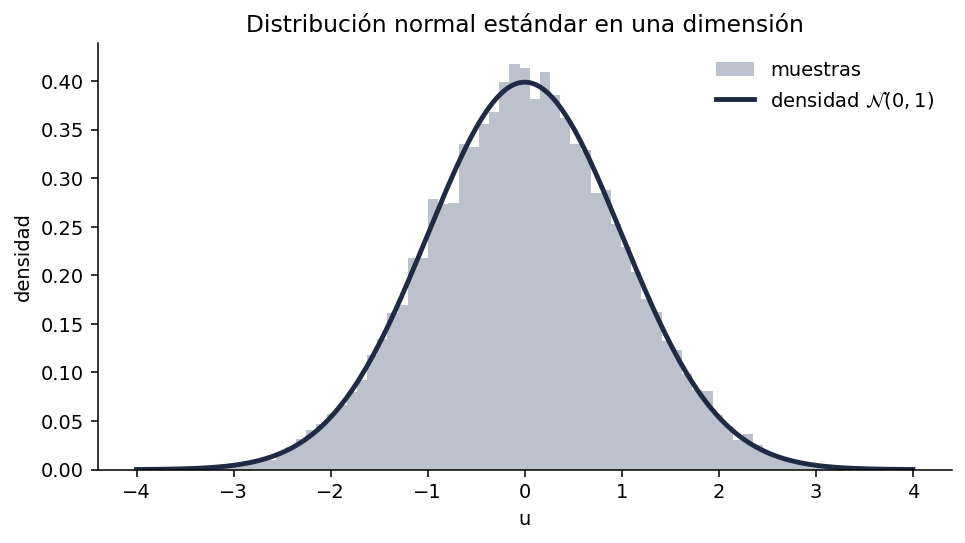

In [3]:
u = RNG.normal(loc=0.0, scale=1.0, size=20_000)
grid = np.linspace(-4, 4, 400)
density = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * grid**2)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(u, bins=70, density=True, alpha=0.65, color="#98a2b3", label="muestras")
ax.plot(grid, density, color="#1f2a44", linewidth=2.5, label=r"densidad $\mathcal{N}(0,1)$")
ax.set_title("Distribución normal estándar en una dimensión")
ax.set_xlabel("u")
ax.set_ylabel("densidad")
ax.legend(frameon=False)
fig.tight_layout()

## Ruido gaussiano como imagen

Una muestra $z \sim \mathcal{N}(0,I_{784})$ es un vector de 784 componentes. Si reorganizamos ese vector como una matriz de tamaño `28x28`, obtenemos una imagen de ruido. Esta operación no le agrega semántica al ruido; solo lo representa con la misma geometría computacional que las imágenes del dataset.

Para visualizarlo, reescalamos cada muestra a `[0,1]`. Ese reescalado es solo gráfico; la muestra matemática original sigue siendo gaussiana.

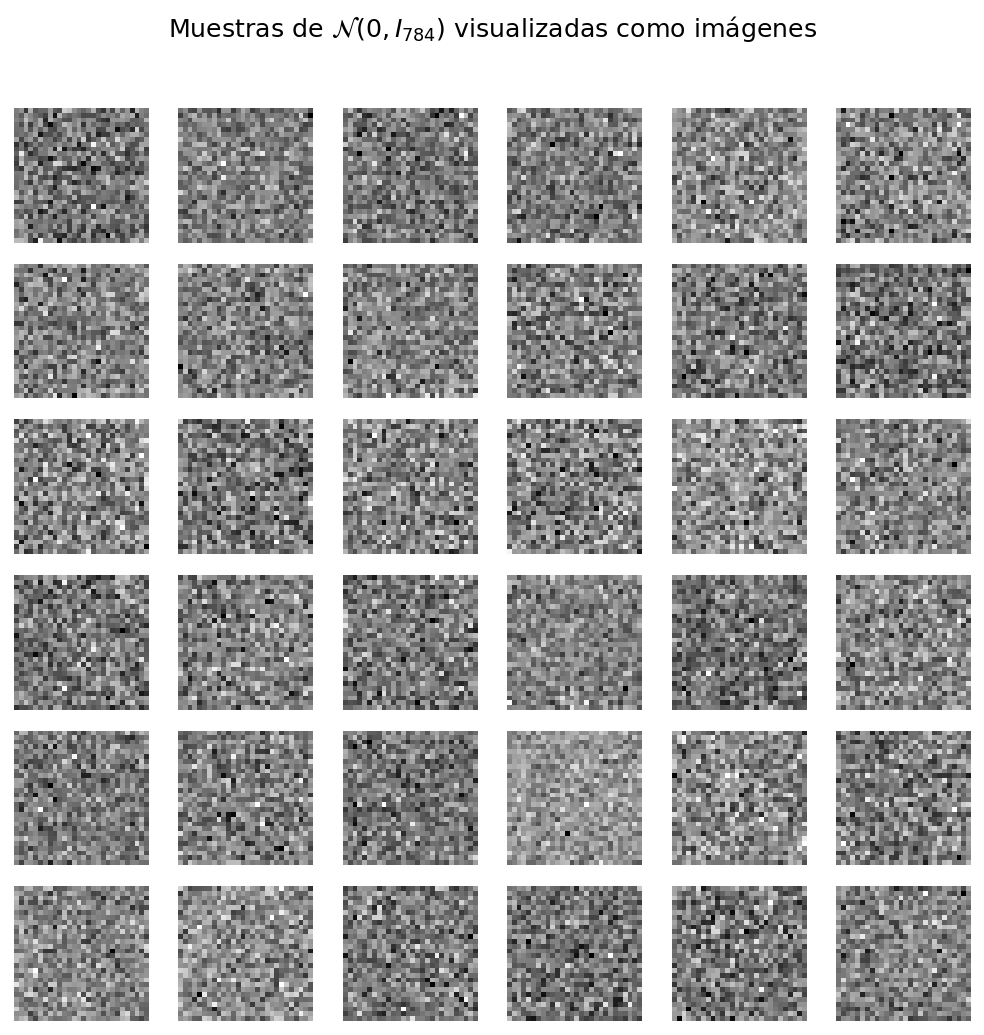

In [4]:
def gaussian_noise_images(num_images, height=28, width=28, seed=0):
    rng = np.random.default_rng(seed)
    z = rng.normal(loc=0.0, scale=1.0, size=(num_images, height, width))
    z_min = z.min(axis=(1, 2), keepdims=True)
    z_max = z.max(axis=(1, 2), keepdims=True)
    z_vis = (z - z_min) / (z_max - z_min + 1e-8)
    return z, z_vis


def show_grid(images, n=36, title=None, vmin=0, vmax=1, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(images), size=n, replace=False)
    cols = int(np.sqrt(n))
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.2, rows * 1.2))
    axes = np.asarray(axes).ravel()
    for ax, image in zip(axes, images[idx]):
        ax.imshow(image, vmin=vmin, vmax=vmax)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    if title:
        fig.suptitle(title, y=1.02, fontsize=13)
    fig.tight_layout()

z_raw, z_vis = gaussian_noise_images(500, h, w, seed=31)
show_grid(z_vis, n=36, title=r"Muestras de $\mathcal{N}(0,I_{784})$ visualizadas como imágenes")

Visualmente, estas muestras no parecen casas. Sin embargo, viven en el mismo espacio vectorial que las casas. Esta distinción es central: el espacio de representación es el mismo, pero la distribución que produce los puntos es distinta.

## Datos y ruido en el mismo espacio

Tomemos una muestra real $x$ del dataset y una muestra gaussiana $z$. Ambas pueden representarse como vectores de dimensión 784, pero sus componentes tienen propiedades estadísticas distintas. La muestra real presenta estructura espacial; la muestra gaussiana tiene componentes independientes antes de reorganizarse como imagen.

x como imagen: (28, 28); x como vector: (784,)
z como imagen: (28, 28); z como vector: (784,)


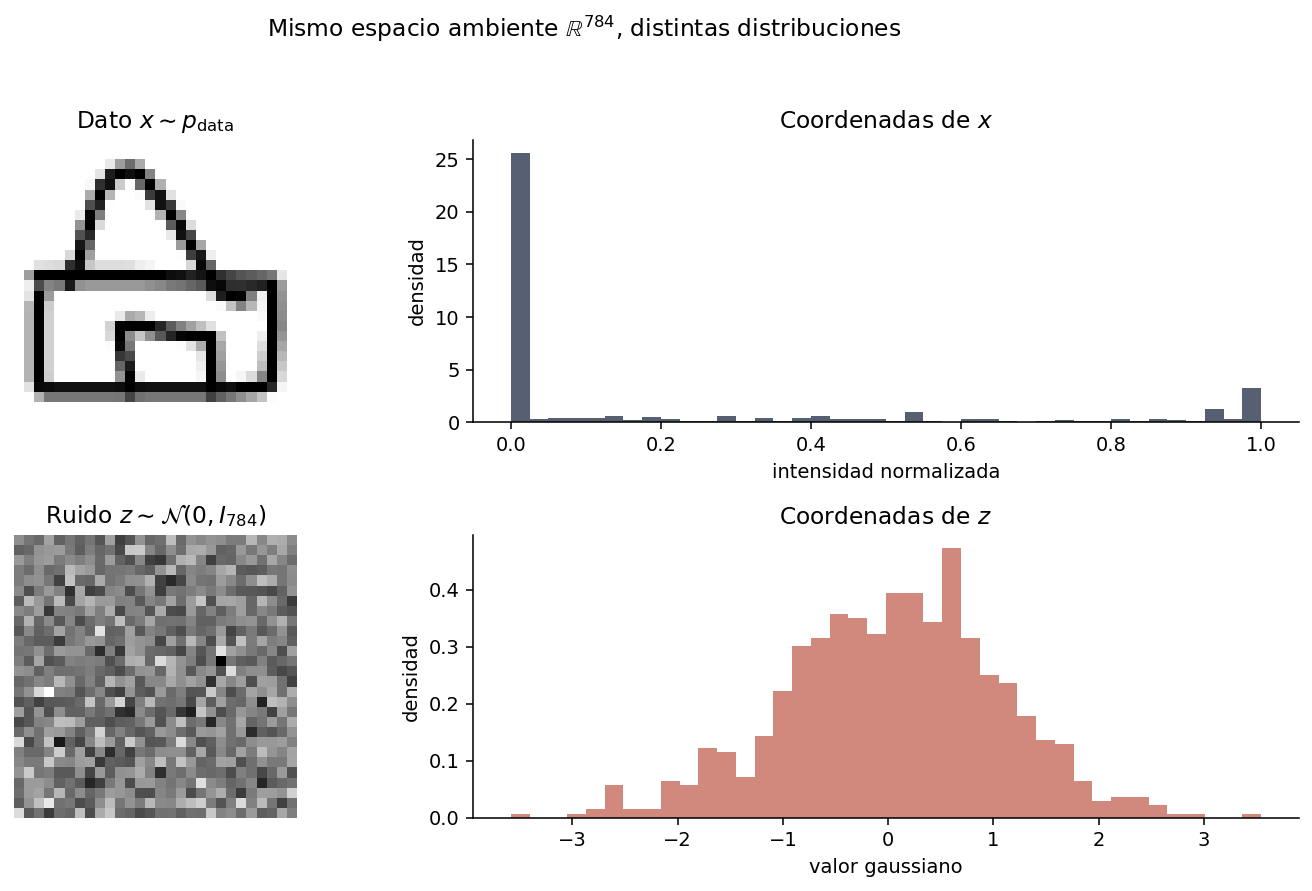

In [5]:
x_example = x_data[0]
z_example = z_raw[0]
z_example_vis = z_vis[0]

x_vector = x_example.reshape(-1)
z_vector = z_example.reshape(-1)

print(f"x como imagen: {x_example.shape}; x como vector: {x_vector.shape}")
print(f"z como imagen: {z_example.shape}; z como vector: {z_vector.shape}")

fig, axes = plt.subplots(2, 2, figsize=(10.5, 6.2), gridspec_kw={"width_ratios": [1.0, 1.45]})

axes[0, 0].imshow(x_example, vmin=0, vmax=1)
axes[0, 0].set_title(r"Dato $x \sim p_{\mathrm{data}}$")
axes[0, 0].axis("off")

axes[1, 0].imshow(z_example_vis, vmin=0, vmax=1)
axes[1, 0].set_title(r"Ruido $z \sim \mathcal{N}(0,I_{784})$")
axes[1, 0].axis("off")

axes[0, 1].hist(x_vector, bins=40, density=True, color="#1f2a44", alpha=0.75)
axes[0, 1].set_title(r"Coordenadas de $x$")
axes[0, 1].set_xlabel("intensidad normalizada")
axes[0, 1].set_ylabel("densidad")
axes[0, 1].set_xlim(-0.05, 1.05)

axes[1, 1].hist(z_vector, bins=40, density=True, color="#c05746", alpha=0.70)
axes[1, 1].set_title(r"Coordenadas de $z$")
axes[1, 1].set_xlabel("valor gaussiano")
axes[1, 1].set_ylabel("densidad")

fig.suptitle(r"Mismo espacio ambiente $\mathbb{R}^{784}$, distintas distribuciones", y=1.02)
fig.tight_layout()


La comparación anterior evita superponer escalas incompatibles. El dato $x$ está normalizado en $[0,1]$ porque sus coordenadas son intensidades de pixeles. El ruido $z$ toma valores reales porque sus coordenadas provienen de normales estándar independientes. Lo importante no es forzar ambos histogramas a vivir en el mismo rango visual, sino reconocer que ambos objetos pueden escribirse como vectores de dimensión 784 mientras son producidos por distribuciones distintas.

Normalizar el ruido a $[0,1]$ puede ser útil para verlo como imagen, pero no debe confundirse con la variable gaussiana original. Si hiciéramos el histograma después de esa normalización visual, estaríamos estudiando una transformación auxiliar del ruido, no la muestra $z \sim \mathcal{N}(0,I_d)$ que se usa como distribución base.


## Concentración de norma en alta dimensión

En dimensión alta, una muestra gaussiana típica no se encuentra cerca del origen. Si $z \sim \mathcal{N}(0,I_d)$, entonces $\|z\|^2 \sim \chi^2_d$ y $\mathbb{E}[\|z\|^2]=d$. Por ello, la norma $\|z\|$ se concentra alrededor de $\sqrt{d}$.

La siguiente simulación muestra el comportamiento de $\|z\|/\sqrt{d}$ para distintas dimensiones.

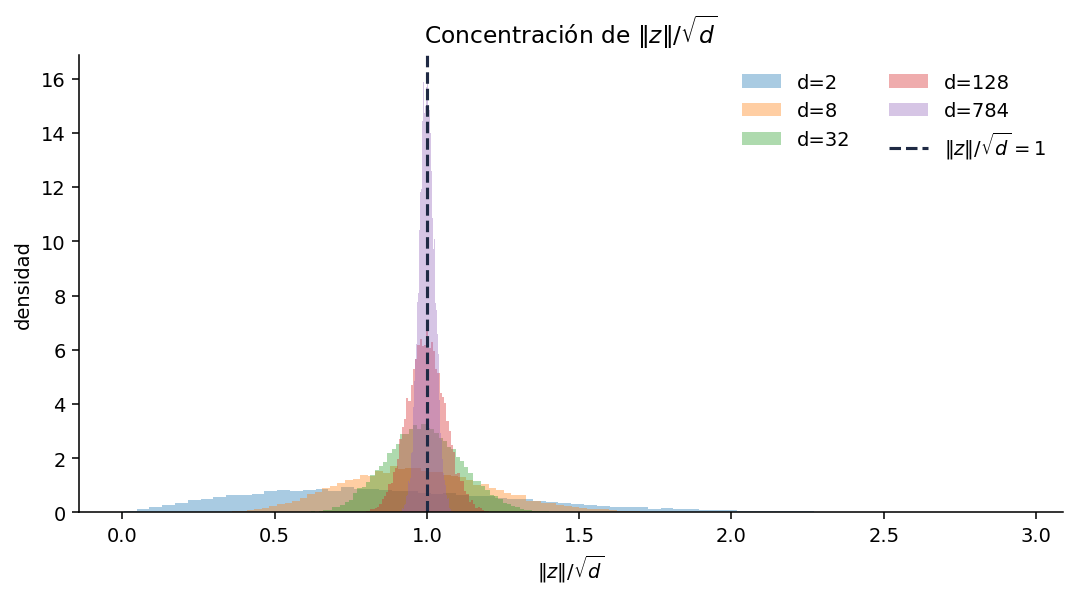

In [6]:
# Parámetros editables: cambie esta lista y vuelva a ejecutar la celda.
dimensiones = [2, 8, 32, 128, 784]
num_muestras = 20_000

fig, ax = plt.subplots(figsize=(7.8, 4.4))
for dim in dimensiones:
    z = RNG.normal(size=(num_muestras, dim))
    normalized_norm = np.linalg.norm(z, axis=1) / np.sqrt(dim)
    ax.hist(normalized_norm, bins=70, density=True, alpha=0.38, label=f"d={dim}")

ax.axvline(1.0, color="#1f2a44", linestyle="--", linewidth=1.6, label=r"$\|z\|/\sqrt{d}=1$")
ax.set_title(r"Concentración de $\|z\|/\sqrt{d}$")
ax.set_xlabel(r"$\|z\|/\sqrt{d}$")
ax.set_ylabel("densidad")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()


La concentración de norma es una propiedad geométrica básica de las gaussianas en alta dimensión. Esto ayuda a evitar una intuición equivocada: aunque la densidad gaussiana es máxima en el origen, una muestra típica en alta dimensión no cae cerca del origen. La mayor parte de la masa probabilística se concentra en una región de radio aproximado $\sqrt{d}$.

## Distribución base y transformación generativa

La utilidad del ruido gaussiano aparece cuando lo usamos como distribución base. En términos abstractos, un modelo generativo puede pensarse como una transformación o procedimiento de muestreo parametrizado que toma ruido como entrada y produce una muestra estructurada:

$$
z \sim \mathcal{N}(0,I_d), \qquad x = G_\theta(z).
$$

En difusión, esta transformación no será una sola función directa necesariamente. Será un procedimiento iterativo que aprenderemos en los próximos notebooks. Por ahora, lo importante es separar los papeles:

$$
\text{distribución simple} \quad \longrightarrow \quad \text{procedimiento aprendido} \quad \longrightarrow \quad \text{distribución de datos}.
$$

## Síntesis

Este notebook estableció el papel del ruido gaussiano dentro del modelado generativo. La distribución $\mathcal{N}(0,I)$ no contiene estructura visual, pero tiene propiedades que la hacen útil: es conocida, fácil de muestrear, isotrópica y matemáticamente simple.

La idea fundamental es que los datos y el ruido pueden vivir en el mismo espacio vectorial, aunque provengan de distribuciones muy diferentes. Además, la gaussiana estándar es simple, pero no trivial en alta dimensión: una muestra típica no aparece cerca del origen, sino en una región de radio aproximado $\sqrt{d}$. Los modelos generativos modernos explotan esta diferencia construyendo procedimientos que transforman muestras de una distribución simple en muestras de una distribución estructurada.


## Preguntas de discusión

1. ¿Por qué no es un problema que una muestra gaussiana no se parezca a una imagen real?
2. ¿Qué significa que $\mathcal{N}(0,I_d)$ sea una distribución en el mismo espacio que las imágenes?
3. ¿Por qué la densidad máxima en el origen no implica que las muestras típicas estén cerca del origen en alta dimensión?
4. ¿Qué diferencia hay entre visualizar ruido como imagen y decir que el ruido tiene estructura semántica?
5. ¿Qué papel cumple una distribución base en un modelo generativo?

## Continuidad

El siguiente notebook introducirá el proceso de difusión directa. Allí dejaremos de comparar datos y ruido como distribuciones separadas y construiremos un camino explícito que transforma progresivamente una muestra de datos $x_0$ en una muestra ruidosa $x_t$.